# Selling Strategy Analysis

## Project

**Copper Recycling Decision System**

### Business Question

> Should an urban recycler sell copper immediately or accumulate inventory over time?

### Objective

Evaluate the impact of inventory accumulation and market price changes on total revenue.

### Background

This analysis is based on observations of informal urban recycling activities in Argentina. Urban recyclers often face a critical decision:

* Sell recovered copper immediately and secure cash flow.
* Accumulate copper inventory and wait for higher market prices.

The purpose of this analysis is to model both scenarios and determine whether waiting can increase profitability.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset

The dataset contains projected scenarios of copper accumulation, expected market prices, and storage costs over a six-month period.


In [7]:
df = pd.read_csv("../data/raw/selling_scenarios.csv")

df

,Mes,Cobre_Acumulado_kg,Precio_ARS,Costo_Almacenamiento
0,1,15,15500,0
1,2,30,17000,5000
2,3,45,18500,10000
3,4,60,20000,15000
4,5,75,21500,20000
5,6,90,23000,25000


# Calculate Gross Revenue

Gross revenue is calculated as:

Revenue = Accumulated Copper × Copper Price


In [8]:
df["Ingreso_Bruto"] = (
    df["Cobre_Acumulado_kg"]
    * df["Precio_ARS"]
)

df

,Mes,Cobre_Acumulado_kg,Precio_ARS,Costo_Almacenamiento,Ingreso_Bruto
0,1,15,15500,0,232500
1,2,30,17000,5000,510000
2,3,45,18500,10000,832500
3,4,60,20000,15000,1200000
4,5,75,21500,20000,1612500
5,6,90,23000,25000,2070000


# Calculate Net Revenue

Net revenue considers storage and inventory holding costs.

Net Revenue = Gross Revenue − Storage Cost


In [9]:
df["Ingreso_Neto"] = (
    df["Ingreso_Bruto"]
    - df["Costo_Almacenamiento"]
)

df

,Mes,Cobre_Acumulado_kg,Precio_ARS,Costo_Almacenamiento,Ingreso_Bruto,Ingreso_Neto
0,1,15,15500,0,232500,232500
1,2,30,17000,5000,510000,505000
2,3,45,18500,10000,832500,822500
3,4,60,20000,15000,1200000,1185000
4,5,75,21500,20000,1612500,1592500
5,6,90,23000,25000,2070000,2045000


# Visualize Accumulation Strategy

The following chart shows how net revenue changes as the recycler accumulates copper inventory over time.


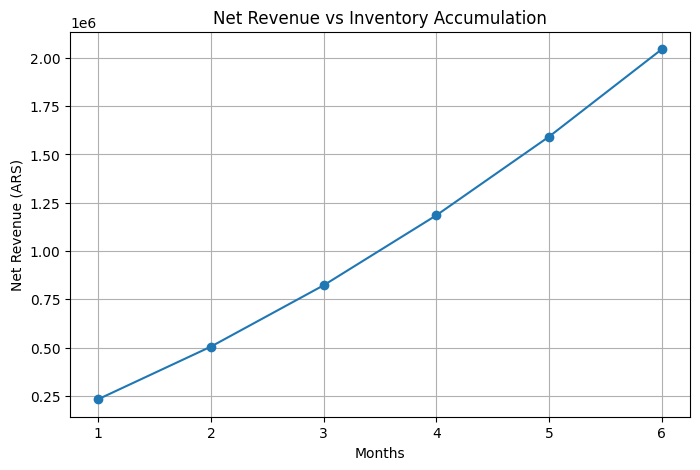

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Mes"],
    df["Ingreso_Neto"],
    marker="o"
)

plt.title(
    "Net Revenue vs Inventory Accumulation"
)

plt.xlabel("Months")
plt.ylabel("Net Revenue (ARS)")

plt.grid(True)

plt.show()

# Preliminary Findings

The analysis suggests that accumulating copper inventory can significantly increase total revenue when market prices are expected to rise.

Key observations:

* Revenue growth is driven by both inventory accumulation and price appreciation.
* Storage costs have a limited impact under the conservative scenario.
* Delaying sales may improve profitability if market conditions remain favorable.
* The decision to sell or wait should consider market risk, storage capacity, and liquidity needs.

## Business Insight

The optimal selling strategy for an urban recycler depends on balancing:

* Expected market price increases.
* Inventory accumulation capacity.
* Storage costs.
* Immediate cash requirements.

This analysis represents the first version of a decision support model for urban copper recyclers.


In [11]:
df.describe()

,Mes,Cobre_Acumulado_kg,Precio_ARS,Costo_Almacenamiento,Ingreso_Bruto,Ingreso_Neto
count,6.000000,6.00000,6.00000,6.000000,6.000000e+00,6.000000e+00
mean,3.500000,52.50000,19250.00000,12500.000000,1.076250e+06,1.063750e+06
std,1.870829,28.06243,2806.24304,9354.143467,6.902730e+05,6.809566e+05
min,1.000000,15.00000,15500.00000,0.000000,2.325000e+05,2.325000e+05
25%,2.250000,33.75000,17375.00000,6250.000000,5.906250e+05,5.843750e+05
50%,3.500000,52.50000,19250.00000,12500.000000,1.016250e+06,1.003750e+06
75%,4.750000,71.25000,21125.00000,18750.000000,1.509375e+06,1.490625e+06
max,6.000000,90.00000,23000.00000,25000.000000,2.070000e+06,2.045000e+06


In [12]:
df.sort_values(
    by="Ingreso_Neto",
    ascending=False
)

,Mes,Cobre_Acumulado_kg,Precio_ARS,Costo_Almacenamiento,Ingreso_Bruto,Ingreso_Neto
5,6,90,23000,25000,2070000,2045000
4,5,75,21500,20000,1612500,1592500
3,4,60,20000,15000,1200000,1185000
2,3,45,18500,10000,832500,822500
1,2,30,17000,5000,510000,505000
0,1,15,15500,0,232500,232500
